# A simulated patient pathway: from SCM to LinearDAGDiscovery

A fictional care pathway gives us a controlled way to explore causal discovery. A pre-existing condition raises disease severity; severity informs diagnosis; diagnosis leads to treatment. Treatment reduces inflammation but can also cause side effects. Inflammation affects function, and function and side effects both affect recovery.

We know the equations used to generate the data, so we can compare an inferred network with ground truth. In a real study, we would not know those equations. We would give LinearDAGDiscovery a candidate network assembled from prior knowledge.

The scores here are fictional and centered. They are not clinical estimates. In the diagrams, green arrows are positive coefficients and orange arrows are negative coefficients.

## 1. Set up the notebook

CORNETO's `Graph.plot` renders the causal networks with Graphviz. Matplotlib draws the paired treatment-effect chart, and pandas displays the simulated dataset. This guide uses CVXPY's direct `HIGHS` solver interface, which requires `highspy`. The project Pixi environment includes these tools; outside it, install CORNETO's plotting extra, pandas, highspy, and the Graphviz executable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from corneto.data import Data
from corneto.graph import Graph
from corneto.methods import LinearDAGDiscovery
from corneto.methods.causal.simulation import Normal, linear_scm

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

## 2. Define the known causal model

Each value in weights is the coefficient in one structural equation. A positive graph sign marks a positive coefficient; a negative sign marks a negative coefficient. Root variables have no parents, so their values come from their noise.

In [2]:
weights = {
    ("comorbidity", "severity"): 0.7,
    ("severity", "diagnosis"): 0.9,
    ("diagnosis", "treatment"): 0.8,
    ("severity", "inflammation"): 0.9,
    ("treatment", "inflammation"): -0.8,
    ("treatment", "side_effects"): 0.5,
    ("comorbidity", "side_effects"): 0.4,
    ("inflammation", "function"): -0.7,
    ("comorbidity", "function"): -0.3,
    ("function", "recovery"): 0.9,
    ("side_effects", "recovery"): -0.4,
    ("severity", "recovery"): -0.2,
}

truth_graph = Graph.from_tuples([
    (source, 1 if weight > 0 else -1, target)
    for (source, target), weight in weights.items()
])

scm = linear_scm(
    truth_graph,
    weights=weights,
    noise=Normal(std=0.5),
)

This is the assumed generating network. The labels show the actual equation coefficients, not merely their signs.

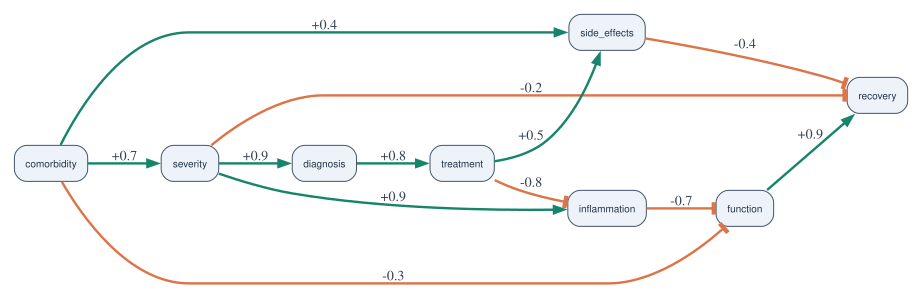

In [3]:
POSITIVE = "#16856b"
NEGATIVE = "#dc7448"

node_style = {
    "shape": "box",
    "style": "rounded,filled",
    "fillcolor": "#edf3f8",
    "color": "#43566b",
    "fontcolor": "#213247",
    "fontname": "Helvetica",
    "fontsize": "10",
    "margin": "0.16,0.09",
}
graph_style = {
    "rankdir": "LR",
    "ranksep": "0.65",
    "nodesep": "0.35",
    "splines": "spline",
    "pad": "0.2",
    "bgcolor": "transparent",
}

truth_edge_order = [
    (next(iter(source)), next(iter(target)))
    for source, target in truth_graph.E
]
truth_edge_styles = {
    index: {
        "color": POSITIVE if weights[edge] > 0 else NEGATIVE,
        "fontcolor": "#344054",
        "label": f"{weights[edge]:+.1f}",
        "penwidth": "2.4",
    }
    for index, edge in enumerate(truth_edge_order)
}

truth_graph.plot(
    renderer="graphviz",
    graph_attr=graph_style,
    node_attr=node_style,
    custom_edge_attr=truth_edge_styles,
)

Read the pathway from left to right. Treatment has two consequences: it lowers inflammation and raises side effects. Those routes point in different directions for recovery, so a treatment effect is the sum of multiple paths.

## 3. Simulate usual care and two treatment policies

In the observational regime, treatment follows diagnosis. A hard intervention assigns everyone treatment = 1 and replaces the treatment equation. A shift adds one unit to the usual prescription and retains the equation. Both operations return new SCMs; the original SCM stays unchanged.

In [4]:
observed = scm.sample(1_000, rng=42)

fixed_treatment = scm.do({"treatment": 1.0})
treated = fixed_treatment.sample(1_000, rng=43)

extra_treatment = scm.shift({"treatment": 1.0})

### Pair the same simulated patients across policies

Reusing exogenous noise holds patient-specific disturbances fixed. The difference in recovery is then the model's exact total effect of a one-unit treatment increase.

In [5]:
noise = scm.draw_noise(1_000, rng=44)
usual = scm.evaluate(noise)
extra = extra_treatment.evaluate(noise)

recovery_column = scm.variables.index("recovery")
usual_recovery = usual[:, recovery_column]
extra_recovery_values = extra[:, recovery_column]
paired_effect = extra_recovery_values - usual_recovery

np.testing.assert_allclose(paired_effect, 0.304)
paired_effect.mean()

np.float64(0.304)

The two causal pathways explain the result: treatment changes inflammation, which changes function and recovery; it also changes side effects, which affect recovery directly.

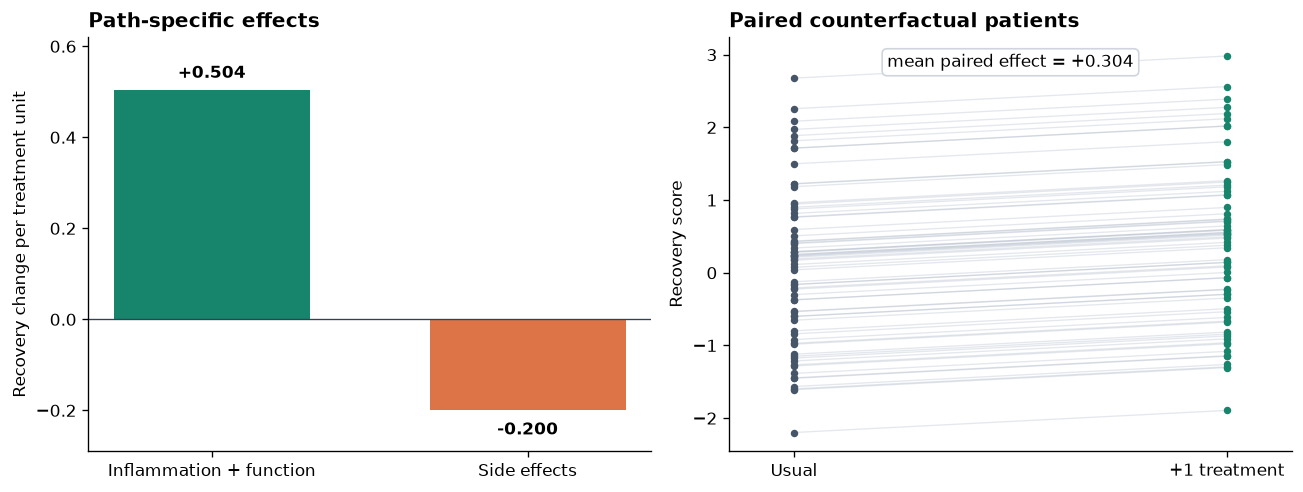

({'Via inflammation and function': 0.504, 'Via side effects': -0.2}, 0.304)

In [6]:
pathway_effects = {
    "Via inflammation and function": (
        weights[("treatment", "inflammation")]
        * weights[("inflammation", "function")]
        * weights[("function", "recovery")]
    ),
    "Via side effects": (
        weights[("treatment", "side_effects")]
        * weights[("side_effects", "recovery")]
    ),
}
total_effect = sum(pathway_effects.values())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
path_names = list(pathway_effects)
path_values = list(pathway_effects.values())
bar_colors = [POSITIVE if value >= 0 else NEGATIVE for value in path_values]
axes[0].bar(range(len(path_values)), path_values, color=bar_colors, width=0.62)
axes[0].axhline(0, color="#344054", linewidth=0.8)
axes[0].set_xticks(range(len(path_names)), ["Inflammation + function", "Side effects"])
axes[0].set_ylabel("Recovery change per treatment unit")
axes[0].set_ylim(-0.29, 0.62)
axes[0].set_title("Path-specific effects", loc="left", fontweight="bold")
for index, value in enumerate(path_values):
    offset = 0.018 if value >= 0 else -0.025
    axes[0].text(index, value + offset, f"{value:+.3f}", ha="center",
                 va="bottom" if value >= 0 else "top", fontweight="bold")

for index in range(70):
    axes[1].plot(
        [0, 1], [usual_recovery[index], extra_recovery_values[index]],
        color="#94a3b8", alpha=0.25, linewidth=0.8,
    )
axes[1].scatter([0] * 70, usual_recovery[:70], color="#475569", s=12, zorder=3)
axes[1].scatter([1] * 70, extra_recovery_values[:70], color=POSITIVE, s=12, zorder=3)
axes[1].set_xticks([0, 1], ["Usual", "+1 treatment"])
axes[1].set_xlim(-0.15, 1.15)
axes[1].set_ylabel("Recovery score")
axes[1].set_title("Paired counterfactual patients", loc="left", fontweight="bold")
axes[1].text(
    0.5, 0.96, f"mean paired effect = {paired_effect.mean():+.3f}",
    transform=axes[1].transAxes, ha="center", va="top",
    bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "#d0d5dd"},
)
fig.tight_layout()
plt.show()

pathway_effects, total_effect

## 4. Generate the dataset

We create four cohorts: usual-care observations, a hard treatment clamp, a known one-unit treatment shift, and a hard comorbidity clamp. The last cohort supplies intervention evidence for causes upstream of treatment. The simulator returns CORNETO `Data` with intervention metadata attached to each affected feature.

In [7]:
observational_data = scm.sample_data(
    200, rng=10, sample_ids=[f"obs_{i}" for i in range(200)]
)
fixed_treatment_data = fixed_treatment.sample_data(
    200, rng=11,
    sample_ids=[f"treated_{i}" for i in range(200)],
    intervention_group="fixed_treatment",
)
shifted_treatment_data = extra_treatment.sample_data(
    200, rng=12,
    sample_ids=[f"shifted_{i}" for i in range(200)],
    intervention_group="extra_treatment",
)
root_intervention = scm.do({"comorbidity": 1.0})
root_intervention_data = root_intervention.sample_data(
    200, rng=13,
    sample_ids=[f"comorbidity_{i}" for i in range(200)],
    intervention_group="comorbidity_clamp",
)

data = Data.from_dict({
    **observational_data.to_dict(),
    **fixed_treatment_data.to_dict(),
    **shifted_treatment_data.to_dict(),
    **root_intervention_data.to_dict(),
})
len(data.samples)

800

### Inspect the dataset in a pandas DataFrame

CORNETO `Data` is organized by sample and feature. The table below gives each sample a readable regime label and shows its intervention group, target, known shift, and measured values for all eight variables. `dataset_df` contains all 800 rows; the preview displays two rows from each group so observational and intervention samples are visible together. The discovery fit still uses the CORNETO `data` object.

In [8]:
records = []
for sample_id, sample in data.samples.items():
    features = {feature.id: feature for feature in sample.features}
    interventions = [
        feature for feature in sample.features
        if feature.data.get("intervention") is not None
    ]
    target_feature = interventions[0] if interventions else None

    if target_feature is None:
        regime = "observational"
        intervention_group = "observational"
        target = "—"
        shift = np.nan
    else:
        intervention_kind = target_feature.data["intervention"]
        regime = "hard intervention" if intervention_kind == "hard" else "known shift"
        intervention_group = target_feature.data.get("intervention_group", regime)
        target = target_feature.id
        shift = target_feature.data.get("shift", np.nan)

    row = {
        "sample_id": sample_id,
        "regime": regime,
        "intervention_group": intervention_group,
        "target": target,
        "shift": shift,
    }
    row.update({variable: features[variable].value for variable in scm.variables})
    records.append(row)

dataset_df = pd.DataFrame.from_records(records)
print(f"Full dataset: {len(dataset_df):,} samples × {len(scm.variables)} measured variables")
display(
    dataset_df.groupby(["regime", "intervention_group"], sort=False)
    .size()
    .rename("samples")
    .to_frame()
)
display(
    dataset_df.groupby("intervention_group", sort=False, group_keys=False)
    .head(2)
    .set_index("sample_id")
)

Full dataset: 800 samples × 8 measured variables


,,samples
regime,intervention_group,
observational,observational,200
hard intervention,fixed_treatment,200
known shift,extra_treatment,200
hard intervention,comorbidity_clamp,200


,regime,intervention_group,target,shift,comorbidity,severity,diagnosis,treatment,inflammation,side_effects,function,recovery
sample_id,,,,,,,,,,,,
obs_0,observational,observational,—,NaN,-0.551669,-1.227794,-1.592506,-1.833276,-0.491915,-1.554752,-0.222345,0.416006
obs_1,observational,observational,—,NaN,-0.362512,0.690132,0.971579,1.103918,0.515836,0.801944,0.608647,0.483183
treated_0,hard intervention,fixed_treatment,treatment,NaN,0.017096,0.283780,0.441831,1.000000,0.276605,1.592916,-0.136860,-1.340976
treated_1,hard intervention,fixed_treatment,treatment,NaN,0.679874,-0.249092,-0.599340,1.000000,-1.641747,1.681109,0.448926,-0.796452
shifted_0,known shift,extra_treatment,treatment,1.0,-0.003413,-0.840287,-0.832065,0.567969,-0.964157,0.247739,0.418671,1.290827
shifted_1,known shift,extra_treatment,treatment,1.0,0.523072,-0.266551,0.263533,1.812471,-2.127902,1.837178,1.335773,0.930986
comorbidity_0,hard intervention,comorbidity_clamp,comorbidity,NaN,1.000000,1.613378,1.496272,2.063336,-0.181158,1.463127,-0.634565,-1.645963
comorbidity_1,hard intervention,comorbidity_clamp,comorbidity,NaN,1.000000,-0.839166,-1.133888,-1.146170,0.279157,-0.102263,-0.464783,-0.125172


The table is a readable view of the same CORNETO `Data` object. Intervention details are stored on the target feature; here is the known shift metadata discovery receives for one shifted sample.

In [9]:
data.samples["shifted_0"].query.filter(
    lambda feature: feature.id == "treatment"
).to_list()[0].data

{'id': 'treatment',
 'value': 0.5679692800501424,
 'mapping': 'vertex',
 'intervention': 'shift',
 'shift': 1.0,
 'intervention_group': 'extra_treatment'}

## 5. Give discovery a candidate graph

The simulator's ground-truth graph is not the discovery input. Here we build a separate candidate network containing all generating edges plus three plausible alternatives. One alternative points back from inflammation to treatment, so the candidate graph contains a cycle. The selected graph must be acyclic.

In [10]:
extra_candidates = {
    ("comorbidity", "diagnosis"): 1,
    ("diagnosis", "inflammation"): 1,
    ("inflammation", "treatment"): 1,
}
candidate_signs = {
    **{edge: (1 if weight > 0 else -1) for edge, weight in weights.items()},
    **extra_candidates,
}
candidate_graph = Graph.from_tuples([
    (source, sign, target)
    for (source, target), sign in candidate_signs.items()
])
candidate_edges = [
    (next(iter(source)), next(iter(target)))
    for source, target in candidate_graph.E
]
len(candidate_edges), len(weights), candidate_graph.num_edges

(15, 12, 15)

The PKN signs constrain coefficient directions because `enforce_signs` is enabled. The simulator's numerical weights are not passed into the fit. The edge penalty favors a smaller explanation; repeat the fit with scientifically reasonable penalty values when assessing stability.

This example uses CVXPY's direct `HIGHS` interface via `highspy`. The selected structure can vary with the sample seed, candidate graph, and modeling assumptions.

In [11]:
method = LinearDAGDiscovery(
    lambda_edges=0.05,
    coefficient_bound=5.0,
    fit_intercept=False,
    max_parents=4,
    enforce_signs=True,
    min_abs_coefficient=0.05,
)
method.fit(candidate_graph, data, solve_options={"solver": "HIGHS"})
method.solve_result.status

'optimal'

## 7. Compare the fit with the known equations

Use the simulator's weights only after fitting, to score the inferred structure. Precision and recall summarize this one simulated run; they are diagnostics, not probabilities that an edge is biologically true.

In [12]:
selected_indices = set(method.get_selected_edge_indices())
selected_edges = {candidate_edges[index] for index in selected_indices}
fitted_weights = dict(zip(candidate_edges, method.edge_coefficients, strict=True))
true_edges = set(weights)

true_positives = selected_edges & true_edges
precision = len(true_positives) / len(selected_edges) if selected_edges else 0.0
recall = len(true_positives) / len(true_edges)

print(f"Selected edges: {len(selected_edges)} of {len(candidate_edges)} candidates")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
for edge in candidate_edges:
    status = "selected" if edge in selected_edges else "not selected"
    print(
        f"{edge[0]:>14} → {edge[1]:<14} "
        f"{status:<12} true={weights.get(edge, 0.0):>+5.2f} "
        f"fitted={fitted_weights[edge]:>+6.2f}"
    )

Selected edges: 12 of 15 candidates
Precision: 1.00
Recall:    1.00
   comorbidity → severity       selected     true=+0.70 fitted= +0.78
      severity → diagnosis      selected     true=+0.90 fitted= +0.93
     diagnosis → treatment      selected     true=+0.80 fitted= +0.79
      severity → inflammation   selected     true=+0.90 fitted= +0.94
     treatment → inflammation   selected     true=-0.80 fitted= -0.83
     treatment → side_effects   selected     true=+0.50 fitted= +0.52
   comorbidity → side_effects   selected     true=+0.40 fitted= +0.40
  inflammation → function       selected     true=-0.70 fitted= -0.66
   comorbidity → function       selected     true=-0.30 fitted= -0.36
      function → recovery       selected     true=+0.90 fitted= +0.87
  side_effects → recovery       selected     true=-0.40 fitted= -0.37
      severity → recovery       selected     true=-0.20 fitted= -0.24
   comorbidity → diagnosis      not selected true=+0.00 fitted= -0.00
     diagnosis → infla

The first diagram shows the data-generating model. After fitting, CORNETO plots the candidate network with selected edges emphasized. Unselected candidates are faint; selected extra candidates are purple dashed arrows. Compare the diagrams and metrics, then vary the seed and edge penalty to see which conclusions are stable.

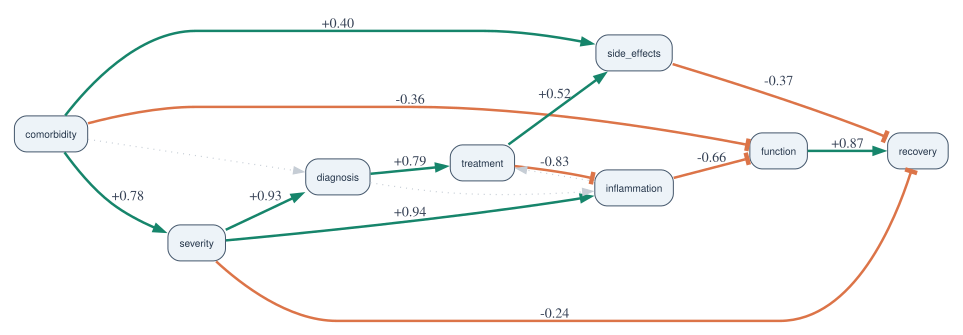

In [13]:
candidate_edge_styles = {}
for index, edge in enumerate(candidate_edges):
    if edge not in selected_edges:
        candidate_edge_styles[index] = {
            "color": "#c6cdd5",
            "style": "dotted",
            "penwidth": "1.2",
        }
    elif edge not in true_edges:
        candidate_edge_styles[index] = {
            "color": "#8057a6",
            "fontcolor": "#8057a6",
            "label": f"{fitted_weights[edge]:+.2f}",
            "style": "dashed",
            "penwidth": "2.5",
        }
    else:
        coefficient = fitted_weights[edge]
        candidate_edge_styles[index] = {
            "color": POSITIVE if coefficient >= 0 else NEGATIVE,
            "fontcolor": "#344054",
            "label": f"{coefficient:+.2f}",
            "penwidth": "2.5",
        }

candidate_graph.plot(
    renderer="graphviz",
    graph_attr=graph_style,
    node_attr=node_style,
    custom_edge_attr=candidate_edge_styles,
)

## What this example teaches

- The SCM records the known equations; the candidate graph records the edges discovery is allowed to consider.
- Hard interventions replace the target equation. Shifts add a known amount while preserving the equation.
- Reusing exogenous noise gives paired counterfactuals and an exact total-effect check.
- Intervention coverage matters. An experiment that only changes treatment does not directly provide intervention paths for causes upstream of treatment.
- A discovered graph is conditional on the candidate network, signs, coefficient threshold, sparsity penalty, and data. Repeat across plausible choices and report instability.

The model is deliberately small and fully observed. Real data may include hidden causes, measurement error, heterogeneous mechanisms, or nonlinear effects that this simulator does not represent.

## 8. Repeat discovery from a complete directed graph

The previous fit searched a compact prior-knowledge network and used its edge signs. Now give discovery every possible directed relationship between the eight variables: 56 edges, including both directions for each pair and no self-loops. This candidate graph has no sign information, so we turn off sign constraints. We reuse the exact same data and the same sparsity and parent-limit settings.

The complete candidate graph includes cycles; the selected model must still be acyclic. The fit can only choose among these candidates, and a larger search space does not add information to the measurements.

In [14]:
complete_variables = tuple(scm.variables)
complete_graph = Graph()
for source in complete_variables:
    for target in complete_variables:
        if source != target:
            complete_graph.add_edge(source, target)

complete_edges = [
    (next(iter(source)), next(iter(target)))
    for source, target in complete_graph.E
]
len(complete_variables), len(complete_edges)

(8, 56)

Fit the complete candidate graph with the same data. With no signed prior knowledge on this graph, coefficient signs are learned from the measurements. A five-minute solver limit keeps this larger search manageable. Setting `verbosity=1` prints the solver progress, including its MIP gap; the cell also reports the final relative gap.

In [15]:
complete_method = LinearDAGDiscovery(
    lambda_edges=0.05,
    coefficient_bound=5.0,
    fit_intercept=False,
    max_parents=4,
    enforce_signs=False,
    min_abs_coefficient=0.05,
)
complete_method.fit(
    complete_graph,
    data,
    solve_options={"solver": "HIGHS", "max_seconds": 300, "verbosity": 1},
)

complete_status = complete_method.solve_result.status
complete_extra_stats = complete_method.solve_result.solver_stats.extra_stats
complete_mip_gap = (
    complete_extra_stats.get("mip_gap")
    if isinstance(complete_extra_stats, dict)
    else getattr(complete_extra_stats, "mip_gap", None)
)
print(f"Solver status: {complete_status}")
print("Final relative MIP gap:", f"{complete_mip_gap:.2%}" if complete_mip_gap is not None else "not reported")

(CVXPY) Sep 24 04:57:28 PM: Your problem has 6598 variables, 19620 constraints, and 0 parameters.


(CVXPY) Sep 24 04:57:28 PM: It is compliant with the following grammars: DCP, DQCP


(CVXPY) Sep 24 04:57:28 PM: DCP verification time: 0.0003 seconds.


(CVXPY) Sep 24 04:57:28 PM: Expression tree has 8 nodes.


(CVXPY) Sep 24 04:57:28 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)


...

corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  cvxpy_problem.solve(solver=s, verbose=verbosity > 0, warm_start=warm_start, **options)
(CVXPY) Sep 24 05:02:28 PM: Problem status: user_limit


(CVXPY) Sep 24 05:02:28 PM: Optimal value: 3.202e+03


(CVXPY) Sep 24 05:02:28 PM: Compilation took 3.527e-02 seconds


(CVXPY) Sep 24 05:02:28 PM: Solver (including time spent in interface) took 3.001e+02 seconds


      3300     133       458   0.37%   2662.968652     3202.060951       16.84%     3813    205   2769     1135k   300.1s
      3300     133       458   0.37%   2662.968652     3202.060951       16.84%     3813    205   2769     1135k   300.1s

Solving report
  Status            Time limit reached
  Primal bound      3202.06095064
  Dual bound        2662.96865157
  Gap               16.84% (tolerance: 0.01%)
  P-D integral      73.1812394158
  Solution status   feasible
                    3202.06095064 (objective)
                    0 (bound viol.)
                    1.93745020027e-11 (int. viol.)
                    0 (row viol.)
  Timing            300.09
                    3.81 (Presolve)
                        MIP    time [calls] = 0.11 [1]
                        subMIP time [calls] = 3.70 [79]
                    296.26 (Solve)
                        MIP    time [calls] = 210.29 [1]
                        subMIP time [calls] = 85.97 [46]
                    0.00 (Postsolv

Compare both fits against the same known equations. The signed prior fit selected all 12 generating edges in this run (precision 1.00, recall 1.00). The complete-graph fit selected 19 edges, including 9 generating edges (precision 0.47, recall 0.75).

HiGHS stopped at the five-minute limit with status `user_limit` and a 16.84% relative MIP gap. It returned a feasible incumbent, but did not prove that the selected structure is optimal. The comparison shows how the candidate set and available prior signs affect discovery on the same measurements.

Candidate network              Candidates  Selected  Precision   Recall
Signed prior graph                     15        12       1.00     1.00
Complete directed graph                56        19       0.47     0.75


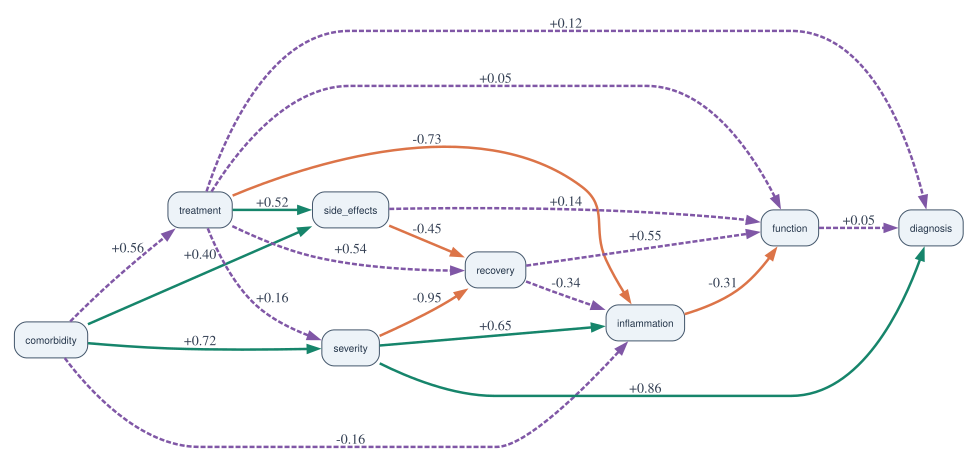

In [16]:
complete_selected_indices = set(complete_method.get_selected_edge_indices())
complete_selected_edges = {complete_edges[index] for index in complete_selected_indices}
complete_fitted_weights = dict(
    zip(complete_edges, complete_method.edge_coefficients, strict=True)
)
complete_true_positives = complete_selected_edges & true_edges
complete_precision = (
    len(complete_true_positives) / len(complete_selected_edges)
    if complete_selected_edges else 0.0
)
complete_recall = len(complete_true_positives) / len(true_edges)

print(f"{'Candidate network':<30} {'Candidates':>10} {'Selected':>9} {'Precision':>10} {'Recall':>8}")
print(f"{'Signed prior graph':<30} {len(candidate_edges):>10} {len(selected_edges):>9} {precision:>10.2f} {recall:>8.2f}")
print(f"{'Complete directed graph':<30} {len(complete_edges):>10} {len(complete_selected_edges):>9} {complete_precision:>10.2f} {complete_recall:>8.2f}")

complete_edge_styles = {}
for index in sorted(complete_selected_indices):
    edge = complete_edges[index]
    coefficient = complete_fitted_weights[edge]
    is_true = edge in true_edges
    complete_edge_styles[index] = {
        "color": (
            (POSITIVE if coefficient >= 0 else NEGATIVE)
            if is_true else "#8057a6"
        ),
        "fontcolor": "#344054",
        "label": f"{coefficient:+.2f}",
        "style": "solid" if is_true else "dashed",
        "penwidth": "2.5",
    }

complete_graph.plot(
    renderer="graphviz",
    edge_indexes=sorted(complete_selected_indices),
    graph_attr=graph_style,
    node_attr=node_style,
    custom_edge_attr=complete_edge_styles,
)